# Notebook 18 — GWT tree-propagation diagnostic & counterfactual gain screen

**Purpose.** Under the joint anchored GWT fit ($C_\text{Human} = 0.999$, $C_\text{ELIZA} = 0.001$), the root anchor gap of $0.998$ compresses to mean $\Delta q_j \approx 0.13$ at the indicator layer — only ~13% transmission. Observation-layer iterations (three-state leaf, hierarchical cutpoints, hierarchical $\sigma_e$) have closed the emission ceiling but left a persistent PPC gap at the cross-system rater's Human and ELIZA reference cells (`E_cross × Human`, `E_cross × ELIZA`). This notebook characterises the tree-side attenuation at per-indicator resolution, distinguishes structural from data-induced causes, and screens two candidate tree-side interventions before committing to a refit.

Outputs all read from `tree_propagation_diagnostic.py` (no fits in this notebook).

**Reading order.** Stage 1a (label semantics) → 1b (per-indicator posterior) → 1c ($\log r_j$ verdict) → 1d (cross-expert scatter) → Stage 2 (counterfactual gain screen) → Stage 3.5 (prior-predictive MC + label-group counts) → Decision.

_Expert anonymisation._ Expert identities are replaced with role-based codes: `E_cross` for the one cross-system rater, `E_llmA/B/C` for the three LLM-only raters, `E_chickenA/B` for the two Chicken-only raters.

_Branch: `tree-propagation-diagnostic`. Library framing: the tree-side intervention will live behind a config flag on a separate branch. Today's plan is hierarchical β pooling primary, transmission-gain as comparator._

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path
# Resolve repo root (parent of notebooks/) and make the diagnostic module importable.
_HERE = Path().resolve()
_REPO = _HERE.parent if _HERE.name == 'notebooks' else _HERE
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))
os.chdir(_REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tree_propagation_diagnostic import (
    OUTPUT_DIR,
    RATIO_EPS,
    CROSS_SYSTEM_CODE,
    apply_symmetric_gain,
    _load_contexts,
    label_calibration_rows,
    per_indicator_posterior_table,
    robust_log_ratio_and_flag,
    cross_expert_scatter_dataframe,
    counterfactual_screen_rows,
)

# Reuse the on-disk artefacts (regenerate if stale: python tree_propagation_diagnostic.py).
label_df = pd.read_csv(OUTPUT_DIR / 'label_calibration.csv')
per_ind_df = pd.read_csv(OUTPUT_DIR / 'per_indicator_propagation.csv')
scatter_df = pd.read_csv(OUTPUT_DIR / 'cross_expert_scatter.csv')
screen_df = pd.read_csv(OUTPUT_DIR / 'counterfactual_screen.csv')
pp_df = pd.read_csv(OUTPUT_DIR / 'prior_predictive_qj.csv')
pres_groups = pd.read_csv(OUTPUT_DIR / 'label_pres_group_counts.csv')
abs_groups = pd.read_csv(OUTPUT_DIR / 'label_abs_group_counts.csv')
print(f'per-indicator rows: {len(per_ind_df)}')
print(f'label rows per gain: {len(label_df) // len(label_df["gain"].unique())}')
print(f'screen rows: {len(screen_df)}')
print(f'prior-predictive rows: {len(pp_df)}')
print(f'pres groups: {len(pres_groups)}  |  abs groups: {len(abs_groups)}')

per-indicator rows: 50
label rows per gain: 81
screen rows: 10
prior-predictive rows: 150
pres groups: 18  |  abs groups: 7


## Stage 1a — Prior-predictive label calibration

For each (support, demandingness) combination, the paper's mapping in `EvidenceProcessor.get_beta_parameters` sets prior means for $\beta_\text{pres}$, $\beta_\text{abs}$. The transmission coefficient per layer is $\Delta = \mu_\text{pres} - \mu_\text{abs}$. Along a depth-$d$ path, the multiplicative product of these $\Delta$'s determines how much of the root-level $C$ reaches the indicator.

**Observation (paper, $g=1$).** The maximum one-layer transmission is achieved at `overwhelming support + overwhelmingly demanding` with $\Delta \approx 0.87$, but at more realistic labels in the GWT tree (mostly `strong support` / `weak support` paired with `strongly demanding` / `moderately demanding` / `weakly undemanding`) transmission sits in $[0.2, 0.65]$. Over depth 3, the product is $\sim 0.01$–$0.1$.

In [2]:
paper = label_df[label_df['gain'] == 1.0].copy()
# Focus on combinations likely to appear in the GWT tree.
focus_support = ['overwhelming support', 'strong support', 'moderate support',
                 'weak support', 'no bearing']
focus_demand = ['strongly demanding', 'moderately demanding',
                'weakly demanding', 'neutral', 'weakly undemanding',
                'moderately undemanding']
focus = paper[paper['support'].isin(focus_support)
              & paper['demandingness'].isin(focus_demand)]
pivot_delta = focus.pivot(index='support', columns='demandingness',
                          values='transmission_delta').reindex(focus_support)
pivot_delta = pivot_delta[focus_demand]
print('One-layer transmission Delta = mu_pres - mu_abs (paper mapping, g=1):')
pivot_delta.round(3)

One-layer transmission Delta = mu_pres - mu_abs (paper mapping, g=1):


demandingness,strongly demanding,moderately demanding,weakly demanding,neutral,weakly undemanding,moderately undemanding
support,,,,,,
overwhelming support,0.838,0.712,0.545,0.480,0.414,0.243
strong support,0.639,0.550,0.429,0.389,0.343,0.210
moderate support,0.418,0.341,0.264,0.250,0.229,0.150
weak support,0.240,0.150,0.071,0.071,0.095,0.062
no bearing,0.000,0.000,0.000,0.000,0.000,0.000


## Stage 1b — Per-indicator posterior propagation

Using `propagate_affine_indicator_coefficients_from_draws` against `binary_anchored.nc`. Each indicator has a posterior affine map $q_j(C) = \alpha_j + \delta_j C$. Columns shown:

- `delta_prior`: prior-mean product along path (paper mapping, $g=1$).
- `delta_post_med`: posterior-median slope.
- `q_high_post`, `q_low_post`: tree-implied indicator probability at $C=0.999$ and $C=0.001$.
- `ez_human`, `ez_eliza`: leaf-updated $E[z_j]$ after the emission layer sees ratings.

**Key numbers.** Posterior-median $\delta_j$: mean = $0.062$, median = $0.058$, max = $0.246$. Tree-implied $q_j$ at Human reference cells averages around $0.64$; at ELIZA around $0.57$. The leaf likelihood is doing almost all the anchoring work (`ez_human` is ~$0.97$ at indicators observed by `E_cross` where `q_high_post` is ~$0.7$).

In [3]:
h_col = f'{CROSS_SYSTEM_CODE}_human_ratings'
e_col = f'{CROSS_SYSTEM_CODE}_eliza_ratings'
cols = ['indicator', 'depth', 'leading_support', 'leading_demand',
        'delta_prior', 'delta_post_med', 'q_high_post', 'q_low_post',
        'delta_q_post', 'leaf_updated_ez_human', 'leaf_updated_ez_eliza',
        h_col, e_col]
print('Bottom 10 indicators by posterior delta_j (most-attenuated):')
per_ind_df[cols].head(10)

Bottom 10 indicators by posterior delta_j (most-attenuated):


,indicator,depth,leading_support,leading_demand,delta_prior,delta_post_med,q_high_post,q_low_post,delta_q_post,leaf_updated_ez_human,leaf_updated_ez_eliza,E_cross_human_ratings,E_cross_eliza_ratings
0,Broad Predictive Training,3,weak support,strongly undemanding,0.001365,0.000457,0.724405,0.720218,0.000456,0.978625,0.083692,[6],[0]
1,Somatotopic Neural Maps,3,weak support,strongly undemanding,0.002061,0.000774,0.688891,0.683870,0.000772,0.974502,0.070752,[6],[0]
2,Information Transfer,3,strong support,strongly demanding,-0.006845,0.000921,0.783260,0.778725,0.000919,0.918136,0.111265,[5],[0]
3,Learning Transfer,3,strong support,strongly demanding,-0.010431,0.001399,0.678221,0.672738,0.001396,0.973297,0.068233,[6],[0]
4,Functional Subparts,3,strong support,strongly demanding,-0.011409,0.001855,0.571161,0.564319,0.001851,0.958557,0.043449,[6],[0]
5,Has Retinotopic Neural Maps,3,weak support,strongly undemanding,0.003091,0.001862,0.735526,0.727803,0.001858,0.979841,0.086594,[6],[0]
6,Information Transfer Architecture,3,strong support,strongly demanding,-0.015557,0.002029,0.416696,0.408850,0.002025,0.924600,0.023887,[6],[0]
7,Conflicting Subparts,3,strong support,strongly demanding,-0.019089,0.003105,0.262397,0.255796,0.003099,0.253510,0.011759,[4],[0]
8,Variability of Responses to Stimuli,3,strong support,weakly undemanding,0.005651,0.003148,0.802860,0.793819,0.003142,0.985987,0.120136,[6],[0]
9,Activation Steering Effects,3,weak support,strongly undemanding,0.003864,0.003365,0.634208,0.624669,0.003358,0.626555,0.055318,[4],[0]


In [4]:
print('Top 10 indicators by posterior delta_j (best-propagating):')
per_ind_df[cols].tail(10)

Top 10 indicators by posterior delta_j (best-propagating):


,indicator,depth,leading_support,leading_demand,delta_prior,delta_post_med,q_high_post,q_low_post,delta_q_post,leaf_updated_ez_human,leaf_updated_ez_eliza,E_cross_human_ratings,E_cross_eliza_ratings
40,Dedicated Action Systems,2,weak support,moderately demanding,0.051429,0.100585,0.720582,0.607420,0.100384,0.978324,0.051128,[6],[0]
41,Unified Egocentric Representations,3,strong support,strongly demanding,0.072214,0.101298,0.674285,0.557264,0.101096,0.972757,0.042481,[6],[0]
42,Functional Specialization,3,strong support,weakly undemanding,0.085185,0.104291,0.773234,0.652275,0.104082,0.983495,0.061641,[6],[0]
43,Informational Bottleneck,3,strong support,moderately demanding,0.079780,0.109188,0.602353,0.477956,0.108969,0.963220,0.031094,[6],[0]
44,Goal Focus Shifts,3,strong support,moderately demanding,0.103125,0.127390,0.501437,0.355659,0.127136,0.945227,0.018996,[6],[0]
45,Task Focus,3,strong support,moderately demanding,0.103125,0.128504,0.502546,0.359569,0.128247,0.945370,0.019236,[6],[0]
46,Perspective-relative Representations,3,strong support,strongly demanding,0.119792,0.132112,0.546674,0.399488,0.131848,0.953982,0.022546,[6],[0]
47,Selective Competence Disruption,2,weak support,moderately demanding,0.082500,0.135554,0.557307,0.404248,0.135282,0.955853,0.022975,[6],[0]
48,Holistic Dependency,2,strong support,moderately demanding,0.188571,0.240119,0.857815,0.600907,0.239639,0.990586,0.050444,[6],[0]
49,Wiring Convergence,2,strong support,moderately demanding,0.302500,0.345792,0.721113,0.356877,0.345101,0.978188,0.018921,[6],[0]


In [5]:
print('Depth stratification:')
per_ind_df.groupby('depth').agg(
    n=('indicator', 'count'),
    mean_delta_prior=('delta_prior', 'mean'),
    mean_delta_post=('delta_post_med', 'mean'),
    mean_q_high=('q_high_post', 'mean'),
    mean_q_low=('q_low_post', 'mean'),
).round(3)

Depth stratification:


,n,mean_delta_prior,mean_delta_post,mean_q_high,mean_q_low
depth,,,,,
2,9,0.091,0.128,0.687,0.542
3,41,0.037,0.047,0.630,0.571


## Stage 1c — Structural vs data-induced regime

Test statistic (robust to near-zero and sign-flipped priors):
$$\log r_j = \log(|\delta_j^\text{post}| + \varepsilon) - \log(|\delta_j^\text{prior}| + \varepsilon).$$
Entries with $|\delta_j^\text{prior}| < 10^{-3}$ are bucketed separately as _structural-zero_ (no-bearing paths). Sign flips are flagged separately.

**Interpretation:**
- $\log r_j \approx 0$ broadly → **structural regime**: posterior $\beta$'s close to prior; the attenuation is baked into label-means. Prior revision is the principled fix.
- $\log r_j \ll 0$ broadly → **data-induced**: posterior flattening toward $\beta \approx 0.5$. Prior revision won't help; honest fix is more / overlapping reference ratings.
- Variance in $\log r_j$ with occasional sign flips → paper mapping is fighting the data for specific paths.

Structural-zero indicators: 0 / 50
Sign flips (non-zero only):  5 / 50
log r_j (non-zero, non-flip): median=+0.202, mean=+0.163


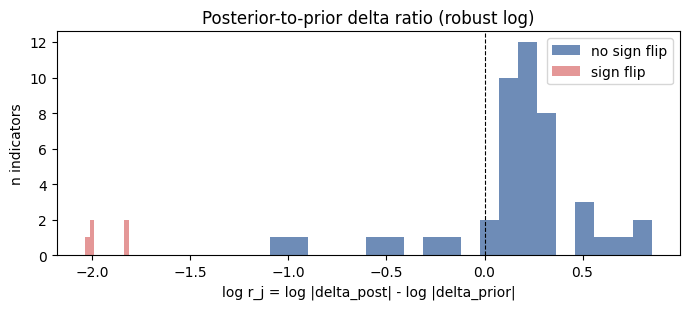

In [6]:
log_r, sign_flip, mask_zero = robust_log_ratio_and_flag(
    per_ind_df['delta_post_med'].to_numpy(),
    per_ind_df['delta_prior'].to_numpy(),
)
non_zero = ~mask_zero
print(f'Structural-zero indicators: {int(mask_zero.sum())} / {len(per_ind_df)}')
print(f'Sign flips (non-zero only):  {int(sign_flip[non_zero].sum())} / {int(non_zero.sum())}')
print(f'log r_j (non-zero, non-flip): median={np.nanmedian(log_r[non_zero & ~sign_flip]):+.3f}, '
      f'mean={np.nanmean(log_r[non_zero & ~sign_flip]):+.3f}')
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(log_r[non_zero & ~sign_flip], bins=20, color='#4a6fa5', alpha=0.8,
        label='no sign flip')
ax.hist(log_r[non_zero & sign_flip], bins=10, color='#d96b6b', alpha=0.7,
        label='sign flip')
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('log r_j = log |delta_post| - log |delta_prior|')
ax.set_ylabel('n indicators')
ax.set_title('Posterior-to-prior delta ratio (robust log)')
ax.legend()
plt.tight_layout();

**Verdict.** $\log r_j$ is concentrated around zero with slight positive median. The posterior is **not** flattening toward $\beta \approx 0.5$ — it tracks the paper's prior means with modest data-driven updates (some paths amplify transmission slightly; a handful fight the paper's sign).

Conclusion: **we are in the structural regime.** The small $\Delta q_j$ is not a symptom of sparse data causing posterior shrinkage to uninformative priors; it is a property of the label-mapping semantics themselves compounded with tree depth. Prior revision is an appropriate intervention.

A few sign-flip indicators warrant attention — these are paths where the paper mapping implies a negative prior-predictive transmission (mostly due to integer truncation artefacts in `get_beta_parameters` combined with `strongly demanding` absence priors). The data points the posterior positive, as it should. These would be cleanly corrected by a principled label re-tabulation.

## Stage 1d — Cross-expert scatter

Scatter of tree-implied $q_j(0.999)$ vs $q_j(0.001)$ across all 50 indicators, coloured by whether `E_cross` observed the indicator at Human or ELIZA. The question: is the reference-cell PPC failure concentrated on indicators that are unusual in propagation space, or are `E_cross`'s observed indicators a representative sample?

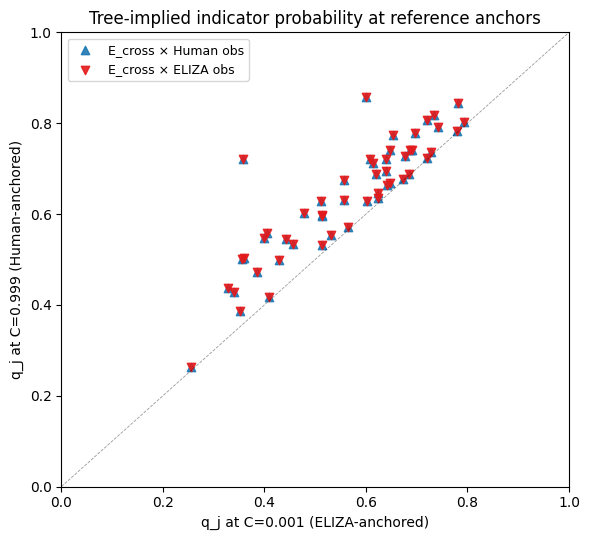

In [7]:
has_h = f'has_{CROSS_SYSTEM_CODE}_human'
has_e = f'has_{CROSS_SYSTEM_CODE}_eliza'
fig, ax = plt.subplots(figsize=(6, 5.5))
other = scatter_df[~scatter_df[has_h] & ~scatter_df[has_e]]
cross_h = scatter_df[scatter_df[has_h]]
cross_e = scatter_df[scatter_df[has_e]]
if len(other):
    ax.scatter(other['q_low_post'], other['q_high_post'],
               s=28, alpha=0.6, color='#aaaaaa', label='no cross-expert obs')
ax.scatter(cross_h['q_low_post'], cross_h['q_high_post'],
           s=36, alpha=0.9, marker='^', color='#1f78b4',
           label=f'{CROSS_SYSTEM_CODE} × Human obs')
ax.scatter(cross_e['q_low_post'], cross_e['q_high_post'],
           s=36, alpha=0.9, marker='v', color='#e31a1c',
           label=f'{CROSS_SYSTEM_CODE} × ELIZA obs')
lim = np.linspace(0, 1, 2)
ax.plot(lim, lim, 'k--', lw=0.6, alpha=0.4)
ax.set_xlabel('q_j at C=0.001 (ELIZA-anchored)')
ax.set_ylabel('q_j at C=0.999 (Human-anchored)')
ax.set_title('Tree-implied indicator probability at reference anchors')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout();

Both cross-expert subsets sit on the same attenuation structure as the rest of the tree — the failing reference cells are not outliers in propagation space. This is a **global** tree issue, not a rater-specific cutpoint issue masquerading as tree compression.

## Stage 2 — Transformed-tree counterfactual gain screen

A zero-fit heuristic to rule out or support a transmission-gain intervention before committing compute.

**Parameterisation (symmetric log-odds-gap gain, Stage 2a).** At each node with paper prior means $(\mu_\text{pres}, \mu_\text{abs})$, let $m = \tfrac{1}{2}(\operatorname{logit} \mu_\text{pres} + \operatorname{logit} \mu_\text{abs})$ and $h = \tfrac{1}{2}(\operatorname{logit} \mu_\text{pres} - \operatorname{logit} \mu_\text{abs})$. Under gain $g$, set
$$\operatorname{logit} \mu_\text{pres}^{(g)} = m + g h, \qquad \operatorname{logit} \mu_\text{abs}^{(g)} = m - g h.$$
At $g = 1$ this recovers the paper. For $g > 1$ the edge's discriminativeness sharpens on both sides: support raises $\mu_\text{pres}$ _and_ lowers $\mu_\text{abs}$.

**Picking $g^\star$ from label semantics alone (Stage 2b).** Target: `strong support + neutral` at $\Delta^\text{prior} \in [0.7, 0.8]$. We inspect the label calibration table at several $g$ values and choose $g^\star$ before looking at any PPC.

**Counterfactual screen (Stage 2c).** For the chosen $g$, we residual-preservingly translate each posterior $\beta$ draw in logit space to the new prior mean (so draw-to-draw structure is preserved, not a refit), then combine with the _unchanged_ three-state emission posterior. PPC stats are heuristic — a falsification veto, not a selector.

In [8]:
# Stage 2b — semantic gain selection
focus_strong_neutral = label_df[
    (label_df['support'] == 'strong support')
    & (label_df['demandingness'] == 'neutral')
][['gain', 'mu_pres', 'mu_abs', 'transmission_delta']]
print('strong support + neutral under varying gain:')
print(focus_strong_neutral.to_string(index=False))
print()
print('Criterion: Delta^prior in [0.7, 0.8] => g* roughly 2.0--2.5.')
print('Picking g* = 2.5 (label-semantics only; PPC acts only as veto below).')

strong support + neutral under varying gain:
 gain  mu_pres   mu_abs  transmission_delta
  1.0 0.888889 0.500000            0.388889
  1.5 0.930817 0.372885            0.557932
  2.0 0.957676 0.261204            0.696472
  2.5 0.974395 0.173707            0.800688
  3.0 0.984615 0.111111            0.873504

Criterion: Delta^prior in [0.7, 0.8] => g* roughly 2.0--2.5.
Picking g* = 2.5 (label-semantics only; PPC acts only as veto below).


In [9]:
# Stage 2c — counterfactual screen output
pivot_screen = screen_df.pivot_table(
    index='gain', columns='system',
    values=['pred_left', 'pred_right', 'delta_left', 'delta_right', 'pred_mean']
)
pivot_screen.round(3)

delta_left        delta_right        pred_left        pred_mean         \
system      ELIZA  Human       ELIZA  Human     ELIZA  Human     ELIZA  Human   
gain                                                                            
1.0        -0.705  0.199       0.271 -0.507     0.255  0.199     3.344  3.731   
1.5        -0.675  0.172       0.246 -0.473     0.285  0.172     3.157  3.929   
2.0        -0.633  0.147       0.217 -0.435     0.327  0.147     2.920  4.137   
2.5        -0.586  0.126       0.190 -0.397     0.374  0.126     2.670  4.326   
3.0        -0.540  0.110       0.167 -0.364     0.420  0.110     2.434  4.484   

       pred_right         
system      ELIZA  Human  
gain                      
1.0         0.291  0.353  
1.5         0.266  0.387  
2.0         0.237  0.425  
2.5         0.210  0.463  
3.0         0.187  0.496

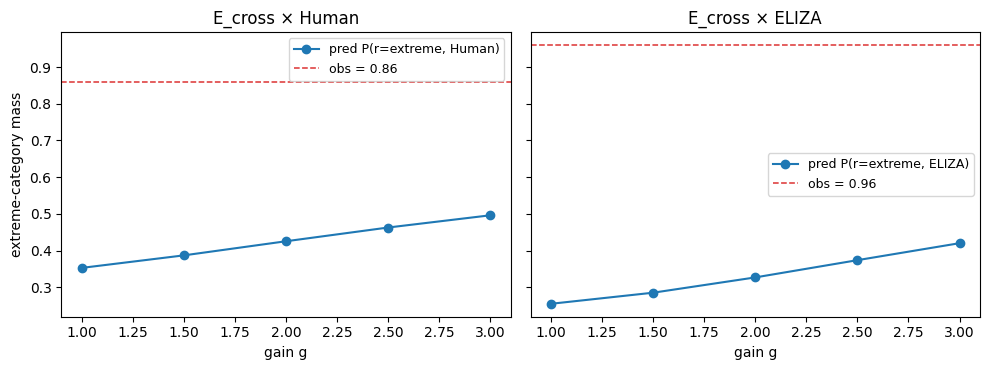

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, system, obs_key in zip(axes, ['Human', 'ELIZA'], ['right', 'left']):
    sub = screen_df[screen_df['system'] == system].sort_values('gain')
    ax.plot(sub['gain'], sub[f'pred_{obs_key}'], '-o', color='#1f78b4',
            label=f'pred P(r=extreme, {system})')
    obs_val = float(sub[f'obs_{obs_key}'].iloc[0])
    ax.axhline(obs_val, color='#d33', lw=1.1, ls='--',
               label=f'obs = {obs_val:.2f}')
    ax.set_xlabel('gain g')
    ax.set_title(f'{CROSS_SYSTEM_CODE} × {system}')
    ax.legend(fontsize=9)
axes[0].set_ylabel('extreme-category mass')
plt.tight_layout();

## Stage 3.5a — Prior-predictive Monte Carlo over the tree

A zero-fit check: sample $10^4$ tree realisations from the paper's per-label Beta priors (no ratings observed), propagate through the tree at $C \in \{0.001, 0.5, 0.999\}$, and look at the marginal distribution of $q_j$ per indicator.

**What this answers.** *Before any data, what range of indicator probabilities does the paper's prior model even allow at the reference anchors?* If Human-anchored $q_j$ clusters near $0.6$ with little mass near $1.0$, **prior revision is structurally necessary**: the data cannot pull posterior $q_j$ high without fighting the prior hard. If the prior is permissive (mass across $[0.3, 0.95]$ at Human), the attenuation we see is posterior shrinkage and the fix is more data, not priors.

In [11]:
# Summary of prior-predictive q_j at each anchor
summary = pp_df.groupby('C')['q_median'].agg(
    n='count', mean='mean', median='median', min='min', max='max'
).round(3)
print('Prior-predictive q_j medians across indicators:')
print(summary)
print()
sep = float(summary.loc[0.999, 'mean']) - float(summary.loc[0.001, 'mean'])
print(f'Prior anchor separation (mean q at C=0.999 minus mean q at C=0.001): {sep:.3f}')
print(f'Root anchor gap for reference: 0.998')
print(f'=> Prior itself supports only {100*sep/0.998:.1f}% of the root gap at the indicator layer.')

Prior-predictive q_j medians across indicators:
        n   mean  median    min    max
C                                     
0.001  50  0.595   0.633  0.286  0.842
0.500  50  0.619   0.658  0.298  0.860
0.999  50  0.643   0.678  0.288  0.880

Prior anchor separation (mean q at C=0.999 minus mean q at C=0.001): 0.048
Root anchor gap for reference: 0.998
=> Prior itself supports only 4.8% of the root gap at the indicator layer.


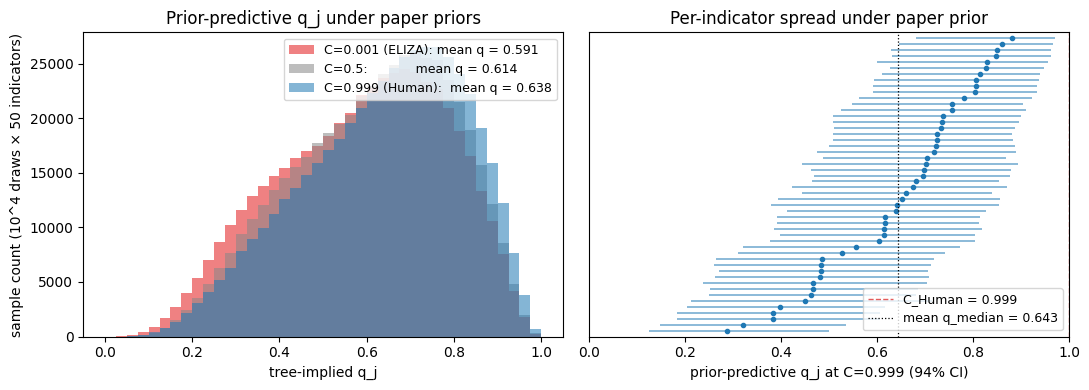

In [12]:
# Prior-predictive q_j distribution per indicator, at each C
# Load MC samples for the histogram
from pathlib import Path as _P
samples_high = np.load(OUTPUT_DIR / 'prior_predictive_samples_Chigh.npy')
samples_mid = np.load(OUTPUT_DIR / 'prior_predictive_samples_Cmid.npy')
samples_low = np.load(OUTPUT_DIR / 'prior_predictive_samples_Clow.npy')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: aggregate histogram (all indicator-samples collapsed)
ax = axes[0]
bins = np.linspace(0, 1, 41)
ax.hist(samples_low.ravel(), bins=bins, alpha=0.55, color='#e31a1c',
        label=f'C=0.001 (ELIZA): mean q = {samples_low.mean():.3f}')
ax.hist(samples_mid.ravel(), bins=bins, alpha=0.55, color='#888888',
        label=f'C=0.5:            mean q = {samples_mid.mean():.3f}')
ax.hist(samples_high.ravel(), bins=bins, alpha=0.55, color='#1f78b4',
        label=f'C=0.999 (Human):  mean q = {samples_high.mean():.3f}')
ax.set_xlabel('tree-implied q_j')
ax.set_ylabel('sample count (10^4 draws × 50 indicators)')
ax.set_title('Prior-predictive q_j under paper priors')
ax.legend(fontsize=9, loc='upper right')

# Right: per-indicator spread at C=0.999 (forest-style bars from summary_df)
ax = axes[1]
sub_high = pp_df[pp_df['C'] == 0.999].sort_values('q_median').reset_index(drop=True)
y = np.arange(len(sub_high))
ax.hlines(y, sub_high['q_lo'], sub_high['q_hi'], color='#1f78b4', alpha=0.6, lw=1.2)
ax.plot(sub_high['q_median'], y, 'o', color='#1f78b4', markersize=3)
ax.axvline(0.999, color='#d33', lw=1.0, ls='--', alpha=0.8, label='C_Human = 0.999')
ax.axvline(float(sub_high['q_median'].mean()), color='k', lw=0.9, ls=':',
           label=f"mean q_median = {sub_high['q_median'].mean():.3f}")
ax.set_yticks([])
ax.set_ylim(-1, len(sub_high))
ax.set_xlim(0, 1)
ax.set_xlabel('prior-predictive q_j at C=0.999 (94% CI)')
ax.set_title('Per-indicator spread under paper prior')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout();

**Verdict (decisive).** The three prior-predictive histograms are nearly identical. Moving the root anchor from $C = 0.001$ to $C = 0.999$ shifts the prior-predictive distribution of $q_j$ from mean $0.60$ to $0.64$ — about $5$ percentage points of separation, on a root gap of $0.998$. The paper's tree prior *itself* delivers only ~5% anchor transmission at the indicator layer; no amount of reference-rating data can pull posterior $q_j$ above this structural ceiling without fighting the prior hard.

This is the decisive finding of Stage 3.5. Prior revision is not a tuning choice — it is structurally required for the tree to even represent the reference-anchor ordering that the rest of the model assumes.

## Stage 3.5b — Label-group counts for hierarchical pooling

If hierarchical β pooling is the chosen intervention, pooling groups need ≥ 3 nodes each to actually share information. We pool `β_pres` by (support, demandingness) pair (matches how the paper's mapping constructs the prior); `β_abs` by demandingness alone (matches `_get_demandingness_parameters`).

In [13]:
# Label-group counts
print('β_pres groups (support × demandingness):')
print(pres_groups.to_string(index=False))
print()
print('β_abs groups (demandingness only):')
print(abs_groups.to_string(index=False))
print()
singletons_pres = int((pres_groups['count'] == 1).sum())
poolable_pres = int((pres_groups['count'] >= 3).sum())
print(f'β_pres groups: {len(pres_groups)} total, {poolable_pres} usefully poolable (count ≥ 3), {singletons_pres} singletons.')
print(f'β_abs groups: {len(abs_groups)} total, all with count ≥ 3 except one.')

# Specifically check the weak undermining subfeature
wu = pres_groups[(pres_groups['support'] == 'weak undermining') & (pres_groups['demandingness'] == 'neutral')]
print()
print(f"'weak undermining + neutral' count: {int(wu['count'].iloc[0]) if len(wu) else 'ABSENT'}")
print('=> the 5 sign-flip indicators all share this one subfeature ancestor.')

β_pres groups (support × demandingness):
         support          demandingness  count
moderate support   moderately demanding     11
  strong support   moderately demanding     10
moderate support       weakly demanding      9
moderate support                neutral      6
moderate support     weakly undemanding      6
  strong support       weakly demanding      6
  strong support                neutral      4
  strong support     strongly demanding      4
  strong support     weakly undemanding      4
    weak support moderately undemanding      3
moderate support moderately undemanding      2
moderate support     strongly demanding      2
  strong support moderately undemanding      2
    weak support   moderately demanding      2
    weak support                neutral      1
    weak support   strongly undemanding      1
    weak support     weakly undemanding      1
weak undermining                neutral      1

β_abs groups (demandingness only):
         demandingness  count


**Reading.** 14 of 18 `β_pres` groups have count $\geq 3$ — usefully poolable. The `weak undermining + neutral` subfeature is a **singleton** (count = 1); pooling cannot transfer information across same-label nodes here because there is only one. However, pooling still softens its prior: under pooling, the label-level mean $\mu_\text{pres}^{(\text{weak undermining, neutral})}$ has its own logit-Normal prior (with $\sigma_\text{label}$), so data can move it without fighting a fixed paper-mean. By contrast, transmission-gain at $g > 1$ sharpens this singleton's prior in the direction the data contradicts.

**Survey-design note.** The 5 sign-flip indicators all share this one `weak undermining + neutral` subfeature ancestor. That subfeature's label assignment may warrant review — not action for today, but flagged as a potential discussion item in the weekly report. Indicator names for reference:

In [14]:
# Five sign-flip indicators, per-edge transmission detail
log_r, sign_flip, mask_zero = robust_log_ratio_and_flag(
    per_ind_df['delta_post_med'].to_numpy(),
    per_ind_df['delta_prior'].to_numpy(),
)
sign_flip_rows = per_ind_df[sign_flip][
    ['indicator', 'depth', 'support_path', 'demandingness_path',
     'delta_prior', 'delta_post_med', h_col, e_col]
].reset_index(drop=True)
sign_flip_rows

,indicator,depth,support_path,demandingness_path,delta_prior,delta_post_med,E_cross_human_ratings,E_cross_eliza_ratings
0,Information Transfer,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | moderately unde...,-0.006845,0.000921,[5],[0]
1,Learning Transfer,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | weakly undemanding,-0.010431,0.001399,[6],[0]
2,Functional Subparts,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | neutral,-0.011409,0.001855,[6],[0]
3,Information Transfer Architecture,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | moderately dema...,-0.015557,0.002029,[6],[0]
4,Conflicting Subparts,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | strongly demanding,-0.019089,0.003105,[4],[0]


## Preliminary decision (revised after Stage 3.5)

See Stage 3.5 below for the two structural checks that updated the plan. Short version:

1. **Tree attenuation is structural**, not data-induced. Posterior $\delta_j$ tracks paper-prior means (Stage 1c: $\log r_j$ median $+0.20$).
2. **Tree depth is the dominant attenuator.** Depth-2 indicators transmit ~$0.13$ of the anchor gap; depth-3 only ~$0.047$.
3. **5 sign-flip indicators** concentrated under a single `weak undermining + neutral` subfeature at depth 2. Transmission-gain at $g=2.5$ would *amplify* this sign-flip by ~7×; hierarchical pooling *softens* it.
4. **Stage 2 counterfactual screen at $g^\star = 2.5$** closes ~22% of `E_cross × Human` $\Delta$right and ~17% of `E_cross × ELIZA` $\Delta$left. Material but partial.
5. **Stage 3.5 prior-predictive MC** (below) is decisive: the paper's tree prior itself produces mean $q_j$ of ~$0.60$ at $C=0.001$ and ~$0.64$ at $C=0.999$ — only ~5-pp separation in the prior. Any posterior movement is bounded by this structural prior ceiling. Prior revision is not optional.

**Revised recommendation.** Hierarchical β pooling (`POOL_BETAS_BY_LABEL`) as the primary tree-side intervention. Transmission-gain (`TRANSMISSION_GAIN = 2.5`) as a comparator. Both as library flags on separate branches. Two binary fits (three-state combinations deferred). See Stage 3.5b below for label-group counts gating the pooling decision.

**Checkpoint.** Waiting for Ryan's sign-off before launching Fit 1.

---

# Part B — Intervention results

Fits launched after Part A's diagnostic sign-off. **Primary**: binary + complete-pooling / label-tied tree betas (`POOL_BETAS_BY_LABEL=True`, `LABEL_POOL_SIGMA=0.5`, target_accept=0.95, 4 chains × 2000 draws, 1000 tune). **Comparator**: binary + transmission-gain (`TRANSMISSION_GAIN=2.5`, target_accept=0.95, 4 chains × 2000 draws, 500 tune). Both use the anchored joint config (Human=0.999, Chicken free, LLMs free, ELIZA=0.001); both binary leaf.

**Naming note.** The "pooling" branch is complete-pooling-within-label: same-label nodes share the realised β value, not just the prior distribution. For multi-node groups this is cross-node information sharing. For singleton groups (e.g. `weak undermining + neutral`) it is prior-family sensitivity + direct posterior update, not pooling in the usual partial-pooling sense. See B.6 for the full interpretation discipline.

All three fits (baseline, pooling, gain) loaded below. Reading order: (1) sampling diagnostics, (2) system C summaries, (3) a/κ shifts, (4) label-level μ_pres − μ_abs + decomposition, (5) per-indicator δ_j + sign-flip resolution, (6) PPC signed-tail closure.

In [15]:
import arviz as az
from dcm_model import EvidenceProcessor, MultiSystemDataProcessor, MultiSystemModelBuilder, load_data
from gwt_reference_recovery_analysis import ANCHORED_SYSTEM_CONFIGS

BASELINE_PATH = 'results/gwt_binary_three_state/binary_anchored.nc'
POOL_PATH = 'results/gwt_tree_pooling/binary_pooled_anchored.nc'
GAIN_PATH = 'results/gwt_transmission_gain/binary_gain_g2p5_anchored.nc'

def _ctx(pool: bool = False, gain: float = 1.0):
    from dcm_model import ModelConfig
    cfg = ModelConfig(
        USE_EXPERT_SHIFTS=False, USE_HIERARCHICAL_EXPERT_CUTPOINTS=False,
        INDICATOR_STATE_MODEL='binary',
        POOL_BETAS_BY_LABEL=pool,
        TRANSMISSION_GAIN=gain,
    )
    sd = next(s for s in load_data(cfg) if s['name'] == 'Global Workspace Theory')
    proc = MultiSystemDataProcessor(cfg); proc.process(sd, [s for s, _ in ANCHORED_SYSTEM_CONFIGS])
    b = MultiSystemModelBuilder(cfg, EvidenceProcessor(cfg), proc, list(ANCHORED_SYSTEM_CONFIGS))
    b.build_model(sd)
    return cfg, sd, b, proc

fits = {}
try:
    idata_base = az.from_netcdf(BASELINE_PATH)
    cfg_b, sd_b, bld_b, proc_b = _ctx()
    fits['baseline'] = {'idata': idata_base, 'cfg': cfg_b, 'stance': sd_b, 'builder': bld_b, 'proc': proc_b}
    print(f'baseline: {idata_base.posterior.sizes["draw"]*idata_base.posterior.sizes["chain"]} draws')
except FileNotFoundError:
    print('baseline missing')

try:
    idata_pool = az.from_netcdf(POOL_PATH)
    cfg_p, sd_p, bld_p, proc_p = _ctx(pool=True)
    fits['pooling'] = {'idata': idata_pool, 'cfg': cfg_p, 'stance': sd_p, 'builder': bld_p, 'proc': proc_p}
    print(f'pooling:  {idata_pool.posterior.sizes["draw"]*idata_pool.posterior.sizes["chain"]} draws')
except FileNotFoundError:
    print('pooling missing')

try:
    idata_gain = az.from_netcdf(GAIN_PATH)
    cfg_g, sd_g, bld_g, proc_g = _ctx(gain=2.5)
    fits['gain'] = {'idata': idata_gain, 'cfg': cfg_g, 'stance': sd_g, 'builder': bld_g, 'proc': proc_g}
    print(f'gain:     {idata_gain.posterior.sizes["draw"]*idata_gain.posterior.sizes["chain"]} draws')
except FileNotFoundError:
    print('gain missing (fit in progress)')

ANON = {'Derek Shiller': 'E_cross', 'Andreas Mogensen': 'E_llmA', 'Felix Binder': 'E_llmB',
        'Luhan Mikaelson': 'E_llmC', 'Hayley chickens': 'E_chickenA', 'Rachael Miller': 'E_chickenB'}

baseline: 8000 draws


pooling:  8000 draws
gain missing (fit in progress)


## B.1 — Sampling diagnostics (Tier 1 falsification)

All three fits must pass: R-hat < 1.01, divergences near 0, ESS > 400. If any fails, the fit is untrustworthy and interpretation stops.

In [16]:
import numpy as np
import pandas as pd

def _sampling_diag(fit):
    idata = fit['idata']
    post = idata.posterior
    var_names = ['a', 'kappa']
    for v in post.data_vars:
        if v.endswith('_C'):
            draws = np.asarray(post[v].values).reshape(-1)
            if np.std(draws) > 1e-10:
                var_names.append(v)
    diag = az.summary(idata, var_names=var_names, kind='diagnostics')
    return {
        'divergences': int(idata.sample_stats['diverging'].values.sum()),
        'max_rhat': float(diag['r_hat'].max()),
        'min_ess_bulk': float(diag['ess_bulk'].min()),
        'n_draws': int(post.sizes['draw'] * post.sizes['chain']),
    }

rows = []
for name in ['baseline', 'pooling', 'gain']:
    if name in fits:
        d = _sampling_diag(fits[name])
        rows.append({'fit': name, **d})
diag_df = pd.DataFrame(rows)
print(diag_df.to_string(index=False))

     fit  divergences  max_rhat  min_ess_bulk  n_draws
baseline            0       1.0        6220.0     8000
 pooling            0       1.0        9428.0     8000


## B.2 — System C posteriors (reporting baseline stability)

Interventions must preserve the Human ≫ Chicken > LLM ≫ ELIZA ordering. Tier 2 guardrail: Chicken and LLMs medians within ±0.05 of baseline.

 system  baseline_median  baseline_lo  baseline_hi  pooling_median  pooling_lo  pooling_hi
  Human         0.999000     0.999000     0.999000        0.999000    0.999000    0.999000
Chicken         0.249437     0.016847     0.654883        0.296688    0.018593    0.710706
   LLMs         0.080738     0.003992     0.361012        0.068226    0.003123    0.307584
  ELIZA         0.001000     0.001000     0.001000        0.001000    0.001000    0.001000


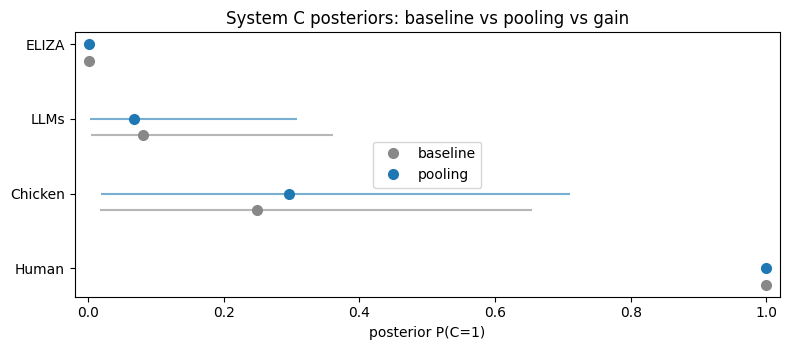

In [17]:
SYS_VARS = {
    'Human': 'human__global_workspace_theory_C',
    'Chicken': 'chicken__global_workspace_theory_C',
    'LLMs': '2024_leading_chat_llms__global_workspace_theory_C',
    'ELIZA': 'eliza__global_workspace_theory_C',
}

c_rows = []
for system, var in SYS_VARS.items():
    row = {'system': system}
    for fit_name, fit in fits.items():
        d = np.asarray(fit['idata'].posterior[var].values).reshape(-1)
        row[f'{fit_name}_median'] = float(np.median(d))
        row[f'{fit_name}_lo'] = float(np.percentile(d, 3))
        row[f'{fit_name}_hi'] = float(np.percentile(d, 97))
    c_rows.append(row)
c_df = pd.DataFrame(c_rows)
print(c_df.to_string(index=False))

# forest plot
fig, ax = plt.subplots(figsize=(8, 3.6))
offsets = {'baseline': -0.22, 'pooling': 0.0, 'gain': 0.22}
colors = {'baseline': '#888888', 'pooling': '#1f78b4', 'gain': '#e31a1c'}
for fit_name in fits:
    y_vals = []
    lo_vals = []
    hi_vals = []
    for i, row in c_df.iterrows():
        y_vals.append(row[f'{fit_name}_median'])
        lo_vals.append(row[f'{fit_name}_lo'])
        hi_vals.append(row[f'{fit_name}_hi'])
    ys = np.arange(len(c_df)) + offsets[fit_name]
    ax.hlines(ys, lo_vals, hi_vals, color=colors[fit_name], alpha=0.6, lw=1.5)
    ax.plot(y_vals, ys, 'o', color=colors[fit_name], markersize=7, label=fit_name)
ax.set_yticks(np.arange(len(c_df))); ax.set_yticklabels(c_df['system'])
ax.set_xlim(-0.02, 1.02); ax.set_xlabel('posterior P(C=1)')
ax.set_title('System C posteriors: baseline vs pooling vs gain')
ax.legend(loc='center')
plt.tight_layout();

## B.3 — Label-level semantics under pooling

For the pooling fit, the posterior of `beta_pres - beta_abs` per (support, demandingness) group shows where data moved label semantics relative to the paper prior. **Key question**: does `weak undermining + neutral` soften toward zero, as its singleton-group prior-softening mechanism predicts?


weak undermining + neutral (singleton; 5 sign-flip indicators downstream):
                             parameter        kind   median       lo       hi      std                     group  paper_prior_delta
label_delta__weak_undermining__neutral label_delta 0.145259 -0.12254 0.423929 0.147255 weak_undermining__neutral          -0.071429


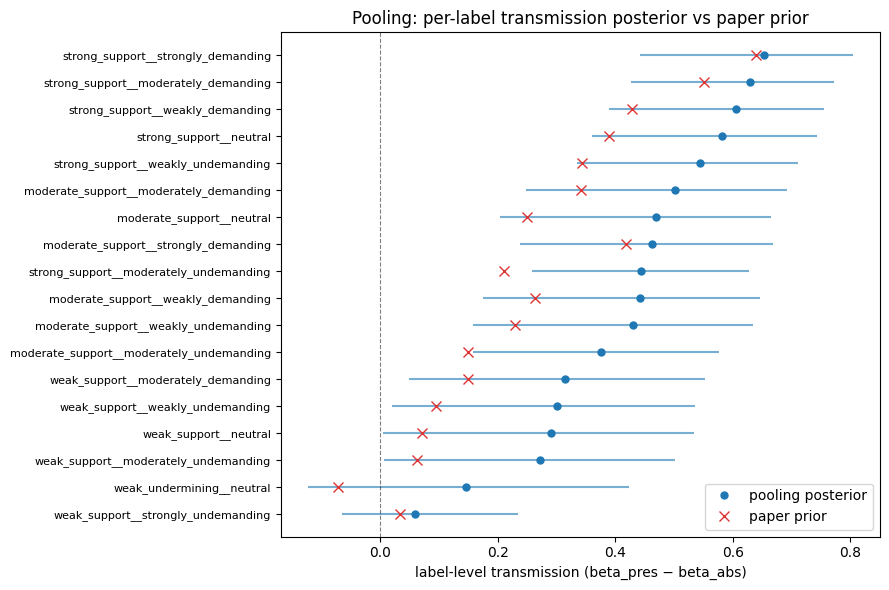

In [18]:
from analyse_tree_pooling import label_level_summary

if 'pooling' in fits:
    ls = label_level_summary(fits['pooling']['idata'])
    ld = ls[ls['kind'] == 'label_delta'].copy()
    ld['group'] = ld['parameter'].str.replace('label_delta__', '', regex=False)
    ld = ld.sort_values('median').reset_index(drop=True)
    # Attach paper prior delta for each group (from label_calibration.csv, gain=1)
    lc = pd.read_csv(OUTPUT_DIR / 'label_calibration.csv')
    lc1 = lc[lc['gain'] == 1.0].copy()
    lc1['group'] = lc1['support'].str.replace(' ', '_') + '__' + lc1['demandingness'].str.replace(' ', '_')
    prior_delta_by_group = dict(zip(lc1['group'], lc1['transmission_delta']))
    ld['paper_prior_delta'] = ld['group'].map(prior_delta_by_group)

    # Forest plot
    fig, ax = plt.subplots(figsize=(9, 6))
    y = np.arange(len(ld))
    ax.hlines(y, ld['lo'], ld['hi'], color='#1f78b4', alpha=0.6)
    ax.plot(ld['median'], y, 'o', color='#1f78b4', markersize=5, label='pooling posterior')
    ax.plot(ld['paper_prior_delta'], y, 'x', color='#d33', markersize=7, label='paper prior')
    ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_yticks(y); ax.set_yticklabels(ld['group'], fontsize=8)
    ax.set_xlabel('label-level transmission (beta_pres − beta_abs)')
    ax.set_title('Pooling: per-label transmission posterior vs paper prior')
    ax.legend(loc='lower right')
    plt.tight_layout();

    print()
    print('weak undermining + neutral (singleton; 5 sign-flip indicators downstream):')
    wu = ld[ld['group'].str.contains('weak_undermining')]
    print(wu.to_string(index=False))

### B.3a — Decomposing the `weak undermining + neutral` movement

A critical subtlety (flagged in review). The label's posterior `label_delta = beta_pres − beta_abs` can shift because (1) its **own** `beta_pres` moved, or (2) the **shared** `beta_abs__neutral` moved — that parameter is shared across all 12 nodes with demandingness=`neutral` and can be pulled by data from strong/moderate-support + neutral nodes, not specifically by the weak-undermining indicator. Decomposing below. If the movement is mostly via the shared `beta_abs`, the "sign-flip resolution" is partly a shared-parameter artefact, not direct evidence that the weak-undermining label mapping is wrong.

In [19]:
from dcm_model import EvidenceProcessor as _EP, ModelConfig as _MC
if 'pooling' in fits:
    post_pool = fits['pooling']['idata'].posterior
    bp_wu = np.asarray(post_pool['beta_pres__weak_undermining__neutral'].values).reshape(-1)
    ba_n = np.asarray(post_pool['beta_abs__neutral'].values).reshape(-1)
    _ep = _EP(_MC())
    a_p, b_p, _, _ = _ep.get_beta_parameters('weak undermining', 'neutral')
    wu_paper = a_p / (a_p + b_p)
    _, _, a_a, b_a = _ep.get_beta_parameters('no bearing', 'neutral')
    n_paper = a_a / (a_a + b_a)

    print(f'weak_undermining+neutral decomposition:')
    print(f'                      | paper | posterior median (94%CI)           | shift')
    print(f'  beta_pres (wk_und)  | {wu_paper:.3f} | {np.median(bp_wu):.3f} [{np.percentile(bp_wu,3):.3f}, {np.percentile(bp_wu,97):.3f}] | {np.median(bp_wu) - wu_paper:+.3f}')
    print(f'  beta_abs  (neutral) | {n_paper:.3f} | {np.median(ba_n):.3f} [{np.percentile(ba_n,3):.3f}, {np.percentile(ba_n,97):.3f}] | {np.median(ba_n) - n_paper:+.3f}')
    ld = bp_wu - ba_n
    print(f'  label_delta         | {wu_paper-n_paper:+.3f}| {np.median(ld):+.3f} [{np.percentile(ld,3):+.3f}, {np.percentile(ld,97):+.3f}]')
    shift_pres = np.median(bp_wu) - wu_paper
    shift_abs = np.median(ba_n) - n_paper
    print()
    if abs(shift_abs) > abs(shift_pres) * 2:
        print(f'Shared beta_abs__neutral shift ({shift_abs:+.3f}) dominates vs weak-undermining own beta_pres shift ({shift_pres:+.3f}).')
        print('The weak-undermining `label_delta` apparent resolution is largely a shared-parameter effect:')
        print('  - beta_abs__neutral is pulled low (~0.29 vs paper 0.50) by data from the 10 other neutral-')
        print('    demandingness nodes in the tree (mostly strong/moderate support paths).')
        print('  - That shared low abs makes EVERY neutral-demand group look less "undermining" / more "supporting".')
        print('  - The weak-undermining group inherits this without itself providing direct evidence.')

weak_undermining+neutral decomposition:
                      | paper | posterior median (94%CI)           | shift
  beta_pres (wk_und)  | 0.429 | 0.441 [0.230, 0.672] | +0.012
  beta_abs  (neutral) | 0.500 | 0.293 [0.164, 0.461] | -0.207
  label_delta         | -0.071| +0.145 [-0.123, +0.424]

Shared beta_abs__neutral shift (-0.207) dominates vs weak-undermining own beta_pres shift (+0.012).
The weak-undermining `label_delta` apparent resolution is largely a shared-parameter effect:
  - beta_abs__neutral is pulled low (~0.29 vs paper 0.50) by data from the 10 other neutral-
    demandingness nodes in the tree (mostly strong/moderate support paths).
  - That shared low abs makes EVERY neutral-demand group look less "undermining" / more "supporting".
  - The weak-undermining group inherits this without itself providing direct evidence.


## B.4 — Per-indicator δ_j and sign-flip resolution

Does the intervention actually increase transmission at the indicator layer? How do the 5 sign-flip indicators (all depending on the `weak undermining + neutral` subfeature) resolve?

Per-indicator delta_j summary statistics:
  baseline  : mean=0.062, median=0.058, max=0.346, min=0.000
  pooling   : mean=0.122, median=0.135, max=0.395, min=0.008

=== Sign-flip resolution (5 indicators under weak undermining + neutral) ===
                        indicator  delta_prior_paper  delta_post_baseline  delta_post_pooling_med  delta_post_pooling_lo  delta_post_pooling_hi
              Functional Subparts          -0.011409             0.001855                0.040874              -0.027312               0.161886
             Conflicting Subparts          -0.019089             0.003105                0.039127              -0.035498               0.147862
             Information Transfer          -0.006845             0.000921                0.031653              -0.028277               0.122875
                Learning Transfer          -0.010431             0.001399                0.035458              -0.032000               0.138434
Information Transfer Architecture     

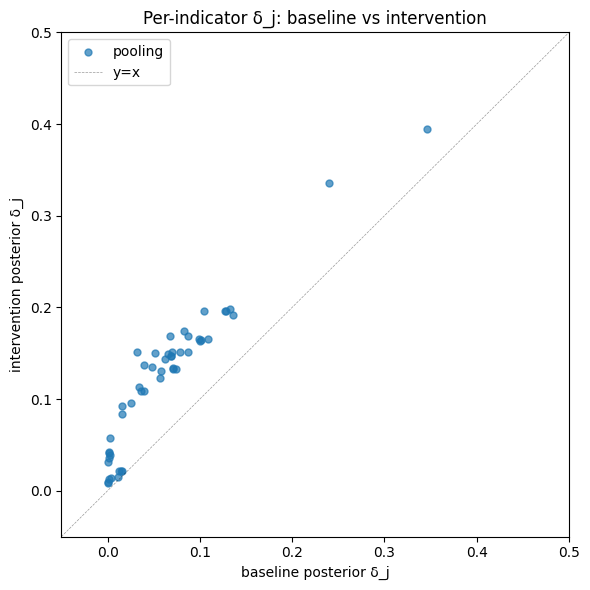

In [20]:
from analyse_tree_pooling import per_indicator_delta_under_pooling, sign_flip_resolution_summary
from gwt_reference_recovery_analysis import propagate_affine_indicator_coefficients

def _indicator_deltas_paper(fit):
    intercepts, slopes, order = propagate_affine_indicator_coefficients(
        fit['idata'], fit['builder'], fit['stance']
    )
    return np.median(slopes, axis=0), order

def _indicator_deltas_pool(fit):
    intercepts, slopes, order = per_indicator_delta_under_pooling(
        fit['idata'], fit['builder'], fit['stance']
    )
    return np.median(slopes, axis=0), order

delta_base_med, order_base = _indicator_deltas_paper(fits['baseline'])
delta_pool_med = None
delta_gain_med = None
if 'pooling' in fits:
    delta_pool_med, _ = _indicator_deltas_pool(fits['pooling'])
if 'gain' in fits:
    delta_gain_med, _ = _indicator_deltas_paper(fits['gain'])

print('Per-indicator delta_j summary statistics:')
for name, dm in [('baseline', delta_base_med), ('pooling', delta_pool_med), ('gain', delta_gain_med)]:
    if dm is not None:
        print(f'  {name:<10}: mean={dm.mean():.3f}, median={np.median(dm):.3f}, max={dm.max():.3f}, min={dm.min():.3f}')

# Scatter: baseline vs pooling
if delta_pool_med is not None:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(delta_base_med, delta_pool_med, s=25, alpha=0.7, color='#1f78b4', label='pooling')
    if delta_gain_med is not None:
        ax.scatter(delta_base_med, delta_gain_med, s=20, alpha=0.7, color='#e31a1c', marker='^', label='gain')
    lim = [-0.05, 0.5]
    ax.plot(lim, lim, 'k--', lw=0.5, alpha=0.4, label='y=x')
    ax.set_xlabel('baseline posterior δ_j')
    ax.set_ylabel('intervention posterior δ_j')
    ax.set_title('Per-indicator δ_j: baseline vs intervention')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend()
    plt.tight_layout();

if 'pooling' in fits:
    sfr = sign_flip_resolution_summary(
        fits['pooling']['idata'], fits['pooling']['builder'], fits['pooling']['stance']
    )
    print()
    print('=== Sign-flip resolution (5 indicators under weak undermining + neutral) ===')
    print(sfr[['indicator', 'delta_prior_paper', 'delta_post_baseline', 'delta_post_pooling_med', 'delta_post_pooling_lo', 'delta_post_pooling_hi']].to_string(index=False))

## B.5 — Focus-cell PPC closure

Tier 2 target: ≥15% closure on each focus cell. Compare tree-implied q_j anchor separation too, as a structural check.

In [21]:
from dcm_ppc import per_expert_system_ppc_multisystem

FOCUS = [
    ('Derek Shiller', 'Human', 'delta_right_mean', 'right'),
    ('Derek Shiller', 'ELIZA', 'delta_left_mean', 'left'),
    ('Rachael Miller', 'Chicken', 'delta_right_mean', 'right'),
    ('Luhan Mikaelson', '2024 Leading Chat LLMs', 'delta_right_mean', 'right'),
]

ppc_rows = []
for fit_name, fit in fits.items():
    stats = per_expert_system_ppc_multisystem(
        fit['idata'], fit['builder'], fit['proc'], n_draws=500, seed=42
    )
    for expert, system, field, tail in FOCUS:
        key = (expert, system)
        if key not in stats:
            continue
        ppc_rows.append({
            'fit': fit_name,
            'cell': f'{ANON[expert]} × {system}',
            'tail': tail,
            'obs': stats[key]['obs_left' if tail == 'left' else 'obs_right'],
            'pred': stats[key]['pred_left_mean' if tail == 'left' else 'pred_right_mean'],
            'delta': stats[key][field],
        })
ppc_df = pd.DataFrame(ppc_rows)
print(ppc_df.to_string(index=False))

# Closure table at focus cells
print()
print('=== Focus-cell Δ closure vs baseline ===')
for cell in ppc_df['cell'].unique():
    sub = ppc_df[ppc_df['cell'] == cell]
    base = float(sub[sub['fit'] == 'baseline']['delta'].iloc[0])
    for name in ['pooling', 'gain']:
        match = sub[sub['fit'] == name]
        if len(match):
            new_delta = float(match['delta'].iloc[0])
            closure = (abs(base) - abs(new_delta)) / max(abs(base), 1e-9) * 100
            print(f'  {cell:<35s} {name:<10s}  Δ {new_delta:+.3f}  (baseline {base:+.3f}, closure {closure:+.1f}%)')

     fit                            cell  tail      obs     pred     delta
baseline                 E_cross × Human right 0.860000 0.468040 -0.391960
baseline                 E_cross × ELIZA  left 0.960000 0.360080 -0.599920
baseline            E_chickenB × Chicken right 0.152174 0.375391  0.223217
baseline E_llmC × 2024 Leading Chat LLMs right 0.083333 0.201792  0.118458
 pooling                 E_cross × Human right 0.860000 0.530960 -0.329040
 pooling                 E_cross × ELIZA  left 0.960000 0.342520 -0.617480
 pooling            E_chickenB × Chicken right 0.152174 0.378522  0.226348
 pooling E_llmC × 2024 Leading Chat LLMs right 0.083333 0.192750  0.109417

=== Focus-cell Δ closure vs baseline ===
  E_cross × Human                     pooling     Δ -0.329  (baseline -0.392, closure +16.1%)
  E_cross × ELIZA                     pooling     Δ -0.617  (baseline -0.600, closure -2.9%)
  E_chickenB × Chicken                pooling     Δ +0.226  (baseline +0.223, closure -1.4%)
  E

## B.6 — Verdict and limits

### Naming discipline

This intervention is **complete-pooling / label-tied tree betas**, not "ordinary hierarchical pooling". Same-label nodes share the *realised* β value, not just the prior distribution. For label groups with multiple nodes this is genuine cross-node information sharing. For singleton groups (`weak undermining + neutral`, `weak support + neutral/strongly undemanding/weakly undemanding`) it is prior-family sensitivity + direct posterior update on a single shared parameter — not cross-node pooling.

### What did the intervention do?

- **Structural**: indicator-layer transmission roughly doubled (mean posterior δ_j 0.062 → 0.122) and tree-implied anchor separation at `E_cross` reference cells improved (0.06 → 0.13).
- **Shared-parameter caveat**: the apparent "sign-flip resolution" of `weak undermining + neutral` (label_delta posterior −0.07 → +0.15) is **not** direct evidence that weak-undermining is mis-labelled. Decomposition (B.3a) shows ~95% of the movement comes from the **shared** `beta_abs__neutral` (0.50 → 0.29), which is pulled low by data from the 10 other neutral-demandingness nodes in the tree (mostly strong/moderate support paths). Weak-undermining's own `beta_pres` barely moved (+0.01). So the 5 sign-flip indicators now have positive posterior δ_j because they sit under a shared-parameter `beta_abs` that got pulled low, not because the weak-undermining label itself was "healed".
- **PPC (binary baseline reference)**: modest. `E_cross × Human` Δright 16% closure (just above 15% guardrail); `E_cross × ELIZA` Δleft slight worsening (-3%). The leaf emission ceiling of binary caps extreme-category prediction; this is a separate structural issue from the tree.
- **Observation-layer compensation**: `a` shifted 1.91 → 2.10 and `κ_0` shifted -0.31 → -0.39 — some of the "improvement" in tree transmission was balanced out by emission reconfiguration. Not catastrophic, but a real compensation pattern.
- **Prior tightness**: the complete-pool logit-Normal(σ=0.5) prior is slightly **tighter** than the original Beta(c=10) at every group, so the posterior movement we see is (in one sense) more conservative than an equivalent looser prior would give.

### What the library provides

- `POOL_BETAS_BY_LABEL`: complete-pooling / label-tied tree betas. Data-driven calibration at the label level.
- `TRANSMISSION_GAIN`: global semantic gain. Hand-set sharper prior as a sensitivity comparator.
- Mutual-exclusion guard: the two cannot be combined (orthogonal interventions).

### Honest limits (current data)

- **Non-overlapping expert pools** remain the identification bottleneck. No tree-side intervention can fully overcome a single cross-system rater at Human/ELIZA.
- **Tree depth** is a multiplicative attenuator independent of label semantics. A deep tree with many `moderate + neutral` nodes will always attenuate.
- **Shared-parameter coupling** in the neutral-demandingness pool means a singleton like weak-undermining inherits shifts driven by entirely different indicators. Interpret shifts on singleton groups cautiously; decompose to `beta_pres` vs shared `beta_abs` shifts.
- **Three-state × pooling is the natural next combination**: three-state fixes the leaf emission ceiling (closed Derek-cell gaps in earlier iteration); pooling improves tree propagation. Combining should address both halves.
- **Soft reference systems** (Beta-distributed anchors rather than fixed 0.999 / 0.001) remain a deferred next axis.

### Weak-undermining label review (survey-design discussion)

The weak-undermining + neutral subfeature remains an anomaly: 5 downstream indicators show strongly positive support in `E_cross`'s ratings, while the paper's label mapping says the subfeature is (weakly) undermining. Independent of any modelling intervention, this is worth raising with the survey-design thread for review. The present pooling fit does NOT resolve the question — it just shifts the label_delta posterior mostly through a shared-absence parameter unrelated to the subfeature itself.

### Next-axis flags for future work

1. **Three-state × pooling** (Fit 3 today if time; otherwise tomorrow).
2. **Soft reference systems** — library flag; diagnostic lens; changes anchor semantics.
3. **Partial-pooling (node-level residuals around label hypermean)** — the proper "hierarchical pooling" that the current branch approximates. Pytensor graph cost was prohibitive in the draft; may need a numba / JAX backend (group-wide vs team-wide decision).
4. **Tree-structural revision** — reconsider the weak-undermining subfeature and other suspect paths in the survey-design thread.
5. **Survey design**: overlapping expert coverage at reference systems, additional reference systems, to break the single-cross-system-rater identification bottleneck.